### A simple example of GMV lensing estimator normalization calculation
This code compute normalization of quadratic estiamtors

In [1]:
# external
import numpy as np, sys
from matplotlib.pyplot import *

In [2]:
# import tempura
import pytempura as tempura

First define parameters

In [3]:
Tcmb  = 2.726e6    # CMB temperature
Lmax  = 3000       # maximum multipole of output normalization
lmax  = 3000
rlmin, rlmax = 2, 3000  # CMB multipole range for reconstruction
nsidet = 2048
L = np.linspace(0,Lmax,Lmax+1)
l = L.copy()
Lfac = (L*(L+1.))**2/(2*np.pi)

Load arrays of lensed CMB Cls. The Cls should not be multiplied by any factors and should not have units.  

In [4]:
lcl = np.zeros((4,lmax+1)) # TT, EE, BB, TE
lcl[:,2:] = np.loadtxt('data/lensedcls.dat',unpack=True,usecols=(1,2,3,4))[:,:lmax-1] 
lcl *= 2.*np.pi / (l**2+l+1e-30) / Tcmb**2

Example noise spectrum

In [5]:
nl = np.zeros((4,lmax+1)) # TT, EE, BB, TE
theta = 1.4*np.pi/10800.
sigma = 8.*np.pi/10800
nl[0] = (sigma/Tcmb)**2*np.exp(l*(l+1)*theta**2/(8.*np.log(2.)))
nl[1] = nl[0]*2.
nl[2] = nl[0]*2.

Define observed CMB cls. Here, no CMB noise.

In [6]:
ocl = lcl+nl # observed Cl

In [7]:
# HOMV normalization
QDO = [True,True,True,True,True,False] # this means that TT, TE, EE, TB and EB are used for MV estimator
Ag, Ac, __, __ = tempura.norm_general.qall('amp',QDO,Lmax,rlmin,rlmax,lcl,lcl,ocl)

In [8]:
# GMV normalization for tau
ag, ac = tempura.norm_general.qgmv('amp',Lmax,rlmin,rlmax,lcl,ocl)

 norm qGMV


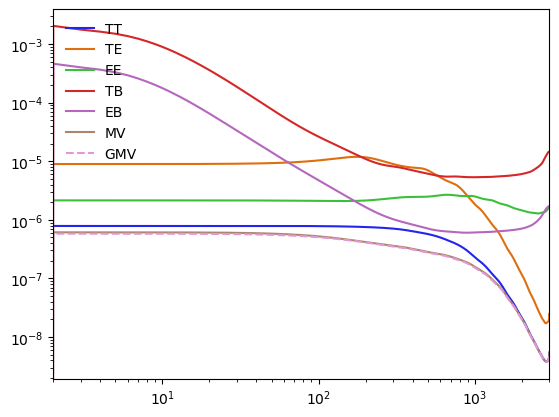

In [9]:
xlim(2,Lmax)
#ylim(1e-8,2e-6)
xscale('log')
yscale('log')
for i, q in enumerate(['TT','TE','EE','TB','EB','MV']):
    plot(L,Ag[i],label=q)
plot(L,ag[5],label='GMV',ls='--')
legend()

/global/homes/t/toshiyan/.conda/envs/py_v3_11/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  func(*args, **kwargs)


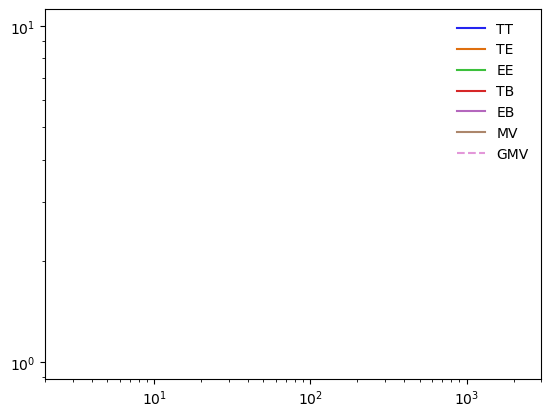

In [11]:
xlim(2,Lmax)
#ylim(1e-8,2e-6)
xscale('log')
yscale('log')
for i, q in enumerate(['TT','TE','EE','TB','EB','MV']):
    plot(L,Ac[i],label=q)
plot(L,ac[5],label='GMV',ls='--')
legend()

/tmp/ipykernel_787863/676931799.py:4: RuntimeWarning: invalid value encountered in divide
  plot(L,ag[5]/Ag[5])
/tmp/ipykernel_787863/676931799.py:5: RuntimeWarning: invalid value encountered in divide
  plot(L,ac[5]/Ac[5])


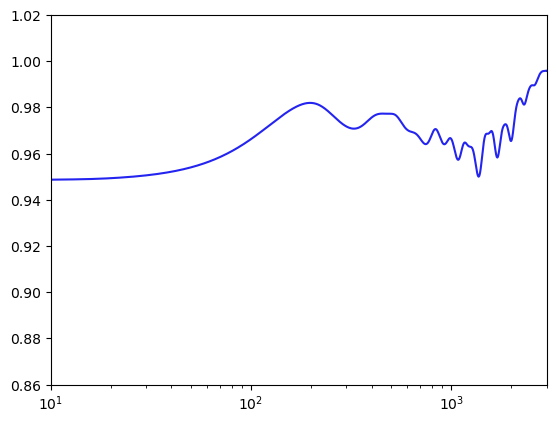

In [10]:
xscale('log')
xlim(10,3000)
ylim(0.86,1.02)
plot(L,ag[5]/Ag[5])
plot(L,ac[5]/Ac[5])